In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential # Builds the layers one by one
from tensorflow.keras.layers import Dense #creates a fully connected layer

2026-05-27 10:25:09.049408: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779877509.331850      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779877509.401983      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779877510.038472      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779877510.038528      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779877510.038531      58 computation_placer.cc:177] computation placer alr

In [2]:
# Create a simple feed forward neural network
model = Sequential() #initialize the model
model.add(Dense(4, activation='relu', input_shape=(2,))) #input layer
model.add(Dense(3, activation='relu')) #hidden layer
model.add(Dense(1, activation='sigmoid')) #output layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-27 10:25:27.159480: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Import libraries
from sklearn.feature_extraction.text import CountVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np


# Sample data # Training texts (movie reviews)
texts = [
    "I love this movie",
    "This film is amazing",
    "Very good acting",
    "Excellent story",
    "I hate this movie",
    "Terrible film",
    "Very boring story",
    "Worst acting ever",
    "Wouldn't recommend wasting your time",
    "Highly recommended for wasting time"
]

# Labels
# 1 = Positive
# 0 = Negative

labels = np.array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0]) # Corrected to match the 10 texts


# Create a Bag-of-Words vectorizer
vectorizer = CountVectorizer()

# Convert texts to numeric vectors
X = vectorizer.fit_transform(texts).toarray()

#Show all words learned from the dataset
print("Vocabulary:")
print(vectorizer.get_feature_names_out())

print("\nNumeric representation:")
print(X)


# Build FFNN
model = Sequential()
# Input layer + hidden layer
#  X.shape[1]: We set the input shape to the number of features (words) in our BoW representation
#8 = number of neurons in hidden layer
model.add(Dense(10,activation='relu',input_shape=(X.shape[1],)))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model architecture
model.summary()

# Train the model
history = model.fit(X, labels,
          epochs=100, #number of times the model will see the entire dataset
          verbose=0) #verbose=0 means no output during training


# Test the model with a new review
new_text = ["Amazing acting and good story"]

# Convert the new text to a numeric vector using the same vectorizer
new_vector = vectorizer.transform(new_text).toarray()

# Make a prediction
prediction = model.predict(new_vector)

print("\nProbability:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Positive Review")
else:
    print("Negative Review")

Vocabulary:
['acting' 'amazing' 'boring' 'ever' 'excellent' 'film' 'for' 'good' 'hate'
 'highly' 'is' 'love' 'movie' 'recommend' 'recommended' 'story' 'terrible'
 'this' 'time' 'very' 'wasting' 'worst' 'wouldn' 'your']

Numeric representation:
[[0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0]
 [0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1]
 [0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0]]


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │           250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Probability: 0.7247859
Positive Review


In [8]:
# Import libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np


# Sample data # Training texts (movie reviews)
texts = [
    "I love this movie",
    "This film is amazing",
    "Very good acting",
    "Excellent story",
    "I hate this movie",
    "Terrible film",
    "Very boring story",
    "Worst acting ever",
    "Wouldn't recommend wasting your time",
    "Highly recommended for wasting time"
]

# Labels
# 1 = Positive
# 0 = Negative

labels = np.array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0]) # Corrected to match the 10 texts


# Create a Bag-of-Words vectorizer
vectorizer_t = TfidfVectorizer()

# Convert texts to numeric vectors
X = vectorizer_t.fit_transform(texts).toarray()

#Show all words learned from the dataset
print("Vocabulary:")
print(vectorizer_t.get_feature_names_out())

print("\nNumeric representation:")
print(X)

print(X.shape)


# Build FFNN
model = Sequential()
# Input layer + hidden layer
#  X.shape[1]: We set the input shape to the number of features (words) in our BoW representation
#8 = number of neurons in hidden layer
model.add(Dense(10,activation='relu',input_shape=(X.shape[1],)))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show model architecture
model.summary()

# Train the model
history = model.fit(X, labels,
          epochs=250, #number of times the model will see the entire dataset
          verbose=0) #verbose=0 means no output during training


# Test the model with a new review
new_text = [ "You can watch if you want to waste time"]
#new_text = ["Amazing acting and good story", "You can watch if you want to waste time"]

# Convert the new text to a numeric vector using the same vectorizer
new_vector = vectorizer_t.transform(new_text).toarray()

# Make a prediction
prediction = model.predict(new_vector)

print("\nProbability:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Positive Review")
else:
    print("Negative Review")

Vocabulary:
['acting' 'amazing' 'boring' 'ever' 'excellent' 'film' 'for' 'good' 'hate'
 'highly' 'is' 'love' 'movie' 'recommend' 'recommended' 'story' 'terrible'
 'this' 'time' 'very' 'wasting' 'worst' 'wouldn' 'your']

Numeric representation:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.66287863
  0.56350739 0.         0.         0.         0.         0.49300238
  0.         0.         0.         0.         0.         0.        ]
 [0.         0.55251242 0.         0.         0.         0.46968604
  0.         0.         0.         0.         0.55251242 0.
  0.         0.         0.         0.         0.         0.41091978
  0.         0.         0.         0.         0.         0.        ]
 [0.54362395 0.         0.         0.         0.         0.
  0.         0.63948886 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.54362395 0.         0.         

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 10)             │           250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Probability: 0.32151058
Negative Review


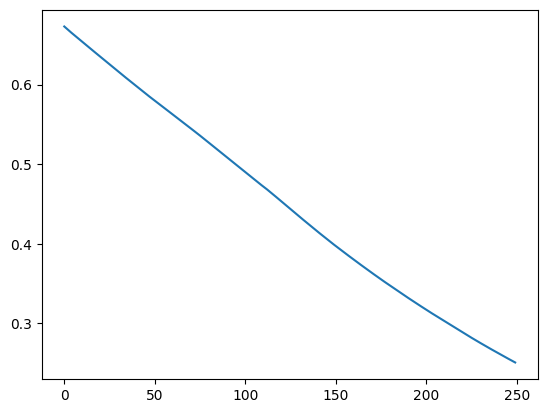

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


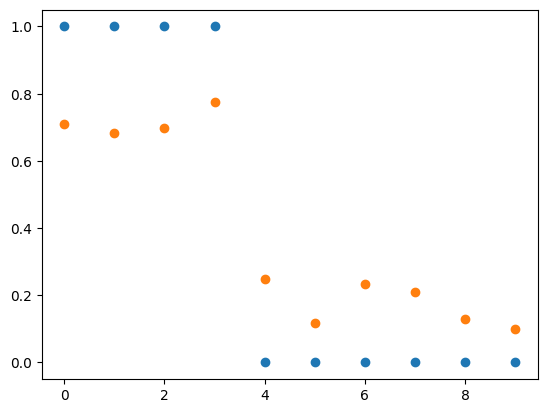

In [9]:
import matplotlib.pyplot as plt
# Training loss
plt.plot(history.history['loss'])
plt.show()

# Predictions
predictions = model.predict(X).flatten()

plt.scatter(range(len(labels)), labels)
plt.scatter(range(len(predictions)), predictions)
plt.show()

In [10]:

# Sample data # Training texts (movie reviews)
texts = [
    "I love this movie",
    "This film is amazing",
    "Very good acting",
    "Excellent story",
    "I hate this movie",
    "Terrible film",
    "Very boring story",
    "Worst acting ever",
    "Wouldn't recommend wasting your time",
    "Highly recommended for wasting time",
]

# Labels: 1 = Positive, 0 = Negative
labels = np.array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0])



# 1. TOKENIZE TEXTS & TRAIN WORD2VEC

# Word2Vec requires tokenized sentences (lists of words) instead of raw strings
sentences = [text.lower().replace("'", "").split() for text in texts]

# Train Word2Vec model using your configuration
w2v_model = Word2Vec(
    sentences=sentences,  # tokenized sentences
    vector_size=50,  # size of word vector
    window=2,  # context window size
    min_count=1,  # include all words
    workers=1,  # number of CPU threads
    sg=1,  # 1 = Skip-gram, 0 = CBOW
)

# Show all words learned from the dataset
print("Vocabulary:")
print(list(w2v_model.wv.key_to_index.keys()))


# 2. CONVERT TEXTS TO DENSE VECTORS (DOCUMENT EMBEDDINGS)
def get_document_vector(tokenized_text, model):
    """Averages word vectors in a text to create a single document vector."""
    valid_words = [word for word in tokenized_text if word in model.wv]

    # If none of the words exist in the model's vocabulary, return zeros
    if not valid_words:
        return np.zeros(model.vector_size)

    # Average the vectors of all valid words in the document
    return np.mean([model.wv[word] for word in valid_words], axis=0)


# Convert training documents into a matrix of dense vectors
X = np.array([get_document_vector(s, w2v_model) for s in sentences])

print("\nNumeric representation shape:")
print(X.shape)  # Out: (10, 50) -> 10 text reviews, each represented by 50 features



# 3. BUILD & TRAIN THE FEEDFORWARD NEURAL NETWORK

model = Sequential()

# Input layer + hidden layer
# X.shape[1] sets the input shape automatically to 50 (your vector_size)
model.add(Dense(10, activation="relu", input_shape=(X.shape[1],)))

# Output layer
model.add(Dense(1, activation="sigmoid"))

# Compile the model
model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

# Train the model
history = model.fit(X, labels, epochs=250, verbose=0)



# 4. TEST THE MODEL WITH A NEW REVIEW

new_text = ["You can watch if you want to waste time"]

# 1. Tokenize the new text just like the training text
tokenized_new = new_text[0].lower().replace("'", "").split()

# 2. Convert to a numeric vector using the same averaging method
new_vector = np.array([get_document_vector(tokenized_new, w2v_model)])

# 3. Make a prediction
prediction = model.predict(new_vector)

print("\nProbability:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Positive Review")
else:
    print("Negative Review")

Vocabulary:
['this', 'time', 'wasting', 'story', 'acting', 'very', 'film', 'movie', 'i', 'for', 'recommended', 'highly', 'your', 'recommend', 'wouldnt', 'ever', 'worst', 'boring', 'terrible', 'hate', 'excellent', 'good', 'amazing', 'is', 'love']

Numeric representation shape:
(10, 50)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Probability: 0.3384068
Negative Review


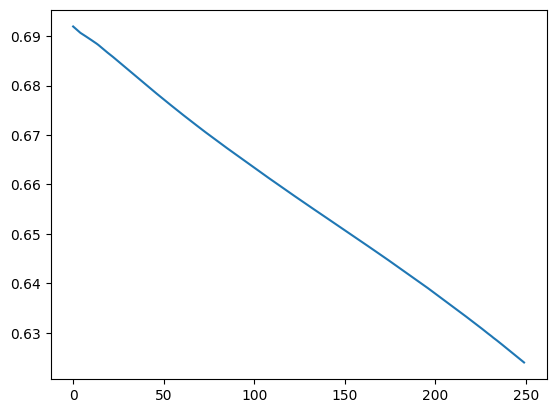

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


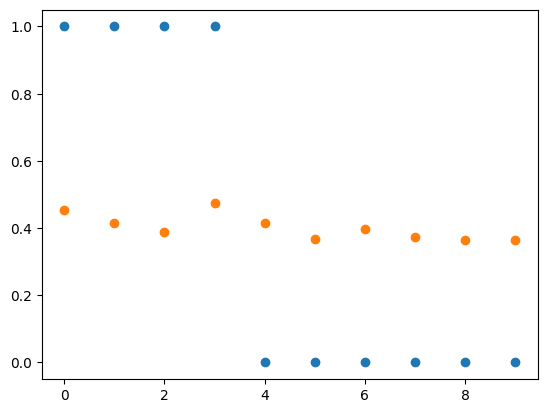

In [11]:
# Training loss
plt.plot(history.history['loss'])
plt.show()

# Predictions
predictions = model.predict(X).flatten()

plt.scatter(range(len(labels)), labels)
plt.scatter(range(len(predictions)), predictions)
plt.show()